# AdaDetect (ERM) on Kaggle Cats vs Dogs

**Goal.** Detect novelties in a test set whose *typical* class is **dog** and where ~5% of the items are **cats** (the novelties), using `AdaDetectERM` from Marandon, Lei, Mary & Roquain — *Machine learning meets FDR* (arXiv:2208.06685, repo: `arianemarandon/adadetect`).

**Why this works / score-function choice.**
AdaDetect computes empirical p-values from a single score function and applies a BH-style step that **provably controls FDR** (under exchangeability of the NTS and the test inliers). Power depends on the score function's ability to separate inliers from outliers. The ERM theory in the paper says: if you train a binary classifier to distinguish the *null training sample* (NTS) from the *test mixture*, the resulting class-probability score converges to the likelihood-ratio (Neyman–Pearson optimal) — i.e. the **most powerful** score at any FDR level.

For images, raw pixels make this classifier hopeless, so we use a **frozen pretrained CNN (ResNet50, ImageNet)** to extract features and then plug a strong tabular learner — `HistGradientBoostingClassifier` — into AdaDetect as the `scoring_fn`. This combo (deep features + gradient-boosted ERM head) is what gives high power while AdaDetect handles FDR control.

**Setup.**
- NTS (`xnull`): only dogs.
- Test sample (`x`): 95% dogs + 5% cats.
- Target FDR level: `alpha = 0.1` (configurable).

In [1]:
import urllib.request
import pathlib

HERE = pathlib.Path.cwd()
PKG_DIR = HERE / "adadetect_pkg"
PKG_DIR.mkdir(exist_ok=True)

files = {
    "procedure.py": "https://raw.githubusercontent.com/arianemarandon/adadetect/main/procedure.py",
    "algo.py": "https://raw.githubusercontent.com/arianemarandon/adadetect/main/algo.py",
}

for fname, url in files.items():
    fpath = PKG_DIR / fname
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)

init_file = PKG_DIR / "__init__.py"
if not init_file.exists():
    init_file.write_text("# local adadetect package\n", encoding="utf-8")

print("AdaDetect package ready at:", PKG_DIR)
for fname in ["__init__.py", "procedure.py", "algo.py"]:
    p = PKG_DIR / fname
    print("-", p.name, p.exists(), p.stat().st_size if p.exists() else 0)


AdaDetect package ready at: c:\Users\h4sor\OneDrive\Desktop\Bachlor\Soren\Adadetect\adadetect_pkg
- __init__.py True 27
- procedure.py True 11173
- algo.py True 3012


## 1. Download the Kaggle cats-vs-dogs archive

This is the same `kagglecatsanddogs_5340.zip` that Kaggle distributes, hosted by Microsoft Research. After unzipping, images live under `PetImages/Cat/*.jpg` and `PetImages/Dog/*.jpg`. A small number of files are corrupt — we filter them out.

In [7]:
import os, zipfile, requests, pathlib
import numpy as np
from PIL import Image


DATA_DIR = HERE / "cats_vs_dogs"
DATA_DIR.mkdir(exist_ok=True)
ZIP_PATH = DATA_DIR / "kagglecatsanddogs_5340.zip"
IMG_ROOT = DATA_DIR / "PetImages"
URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

if not IMG_ROOT.exists():
    if not ZIP_PATH.exists():
        print("Downloading ~800 MB ...")
        with requests.get(URL, stream=True) as r:
            r.raise_for_status()
            with open(ZIP_PATH, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
    print("Unzipping ...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

def list_valid(folder):
    paths = []
    for p in sorted(folder.iterdir()):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        try:
            with Image.open(p) as im:
                im.verify()
            paths.append(p)
        except Exception:
            pass
    return paths

cat_paths = list_valid(IMG_ROOT / "Cat")
dog_paths = list_valid(IMG_ROOT / "Dog")
print(f"valid cats: {len(cat_paths)}   valid dogs: {len(dog_paths)}")

c:\Users\h4sor\miniforge3\envs\dl\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


valid cats: 12499   valid dogs: 12499


## 2. Extract frozen ResNet50 features

We average-pool the final conv block → 2048-d feature per image. Cache to disk so we only do this once.

Set `DOWNSAMPLE_TO = 28` in the next cell to downsample each image before feature extraction (it will still be resized to 224 inside the ImageNet preprocessing).

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from tqdm.auto import tqdm

DOWNSAMPLE_TO = 28  # set to 28 for 28x28 downsample before feature extraction
FEAT_PATH = HERE / (
    "cvd_features.npz"
    if DOWNSAMPLE_TO is None
    else f"cvd_features_{DOWNSAMPLE_TO}x{DOWNSAMPLE_TO}.npz"
 )
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0  # Windows-safe; avoids DataLoader worker crashes
print("device:", DEVICE)

class ImgDataset(Dataset):
    def __init__(self, paths, label, tf):
        self.paths, self.label, self.tf = paths, label, tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tf(img), self.label

def make_preprocess(weights, downsample_to=None):
    base = weights.transforms()
    if downsample_to is None:
        return base
    def _tf(img):
        img_small = img.resize((downsample_to, downsample_to), resample=Image.BICUBIC)
        return base(img_small)
    return _tf

if not FEAT_PATH.exists():
    weights = ResNet18_Weights.IMAGENET1K_V1
    preprocess = make_preprocess(weights, DOWNSAMPLE_TO)
    model = resnet18(weights=weights)
    model.fc = torch.nn.Identity()  # output the 512-d pooled features
    model.eval().to(DEVICE)

    all_paths   = [(p, 0) for p in cat_paths] + [(p, 1) for p in dog_paths]
    paths_only  = [p for p, _ in all_paths]
    labels_only = [y for _, y in all_paths]

    ds = ImgDataset(paths_only, 0, preprocess)

    def collate(batch_idx):
        imgs = torch.stack([ds[i][0] for i in batch_idx])
        ys   = torch.tensor([labels_only[i] for i in batch_idx])
        return imgs, ys

    loader = DataLoader(
        range(len(paths_only)), batch_size=64, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=collate,
    )

    feats, labels = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="extracting"):
            f = model(xb.to(DEVICE)).cpu().numpy()
            feats.append(f)
            labels.append(yb.numpy())

    feats  = np.concatenate(feats).astype(np.float32)
    labels = np.concatenate(labels).astype(np.int64)
    np.savez_compressed(FEAT_PATH, feats=feats, labels=labels)
    print("Saved features:", feats.shape)
else:
    print("Loading cached features from", FEAT_PATH)

data   = np.load(FEAT_PATH)
feats  = data["feats"]
labels = data["labels"]
dogs = feats[labels == 1]
cats = feats[labels == 0]
print("dogs:", dogs.shape, "cats:", cats.shape)


device: cuda


extracting:   0%|          | 0/391 [00:10<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 25928, 18932, 32652, 16140) exited unexpectedly

## 3. Build the AdaDetect inputs

- `xnull`: NTS, only dogs.
- `x`: test sample, 95% dogs + 5% cats.

We keep ground-truth labels for the test set so we can compute realized FDR and power.

In [4]:
def build_problem(rng, n_null=4000, m_test=1000, novelty_frac=0.05):
    """Return xnull, x, is_novelty (bool array, True == cat)."""
    m1 = int(round(novelty_frac * m_test))   # cats in test
    m0 = m_test - m1                         # dogs in test
    dog_idx = rng.permutation(len(dogs))
    cat_idx = rng.permutation(len(cats))
    assert len(dog_idx) >= n_null + m0, "not enough dogs"
    assert len(cat_idx) >= m1, "not enough cats"
    xnull = dogs[dog_idx[:n_null]]
    test_dogs = dogs[dog_idx[n_null : n_null + m0]]
    test_cats = cats[cat_idx[:m1]]
    x = np.concatenate([test_dogs, test_cats], axis=0)
    is_novelty = np.concatenate([np.zeros(m0, bool), np.ones(m1, bool)])
    perm = rng.permutation(len(x))           # shuffle so order is not informative
    return xnull, x[perm], is_novelty[perm]

rng = np.random.default_rng(0)
xnull, x, is_novelty = build_problem(rng, novelty_frac=0.3)
print("xnull", xnull.shape, "  x", x.shape, "  novelties in test:", is_novelty.sum())

xnull (4000, 2048)   x (1000, 2048)   novelties in test: 300


## 4. Run AdaDetectERM

`scoring_fn` should be a sklearn-style classifier with `fit` and `predict_proba`. We use **HistGradientBoostingClassifier**: fast, strong on 2048-d ResNet features, and an excellent ERM-class probability estimator. (`RandomForestClassifier(max_depth=10)` — used in the repo example — is a safe alternative; we benchmark both below.)

`split_size` is the fraction of the *combined* `(xnull, x)` used as the calibration set inside AdaDetect (the rest is used to fit the classifier). The paper / repo example uses `split_size = n / (n + len(x_extra))` where `x_extra` is taken from `xnull`. Here a value around `0.7–0.8` works well.

In [5]:
import sys
sys.path.insert(0, str(HERE))
from adadetect_pkg.procedure import AdaDetectERM
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
ALPHA = 0.10   # target FDR level

def fdp_power(rejected_idx, is_novelty):
    R = len(rejected_idx)
    if R == 0:
        return 0.0, 0.0
    tp = int(is_novelty[rejected_idx].sum())
    fp = R - tp
    fdp = fp / R
    power = tp / max(int(is_novelty.sum()), 1)
    return fdp, power

scorers = {
    "HistGBM": HistGradientBoostingClassifier(max_depth=6, learning_rate=0.1, max_iter=200),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, n_jobs=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=200),
    "logistic": LogisticRegression(max_iter=200), 
}

for name, clf in scorers.items():
    proc = AdaDetectERM(scoring_fn=clf, split_size=0.75)
    rejected = proc.apply(x, ALPHA, xnull)
    fdp, power = fdp_power(np.asarray(rejected, dtype=int), is_novelty)
    print(f"{name:>12s}  |R|={len(rejected):4d}   FDP={fdp:.3f}   Power={power:.3f}")


     HistGBM  |R|= 296   FDP=0.030   Power=0.957
RandomForest  |R|= 319   FDP=0.066   Power=0.993
         MLP  |R|= 299   FDP=0.070   Power=0.927
    logistic  |R|= 311   FDP=0.074   Power=0.960


c:\Users\h4sor\miniforge3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


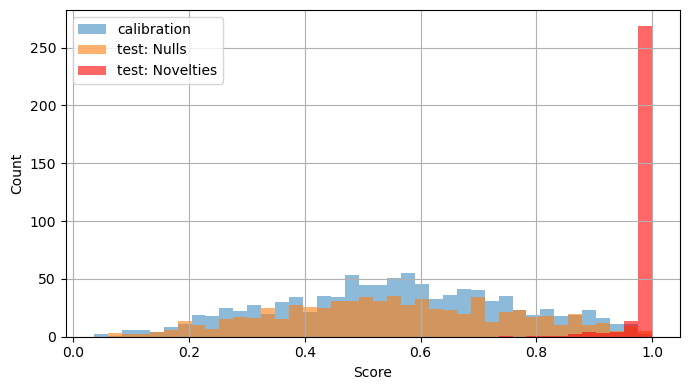

In [6]:
# Plot calibration (null) vs test scores split into true nulls/novelties
cal_scores = proc.null_statistics
test_scores = proc.test_statistics
import matplotlib.pyplot as plt

true_null_scores = test_scores[~is_novelty]
true_novelty_scores = test_scores[is_novelty]

# Use the same bin edges for all histograms
hist_edges = np.histogram_bin_edges(
    np.concatenate([cal_scores, true_null_scores, true_novelty_scores]),
    bins=40
)

fig, ax = plt.subplots(figsize=(7, 4))
plt.grid()
ax.hist(cal_scores, bins=hist_edges, alpha=0.5, label="calibration")
ax.hist(true_null_scores, bins=hist_edges, alpha=0.6, label="test: Nulls")
ax.hist(true_novelty_scores, bins=hist_edges, alpha=0.6, label="test: Novelties", color="red")
ax.set_xlabel("Score")
ax.set_ylabel("Count")
# ax.set_title("Calibration vs test score distribution")
ax.legend()

plt.tight_layout()
fig.savefig("cvd_score_histogram.pdf", bbox_inches="tight")
plt.show()

## 5. Repeat over seeds — empirical FDR and power

FDR control is a guarantee *in expectation*. Average over many random splits to confirm FDR ≤ α and to compare scorers on power.

In [8]:
from tqdm.auto import tqdm

N_REPS = 20
results = {name: {"fdp": [], "power": []} for name in scorers}

for seed in tqdm(range(N_REPS)):
    rng = np.random.default_rng(seed)
    xnull_s, x_s, novelty_s = build_problem(rng)
    for name, clf_proto in scorers.items():
        # fresh estimator per run
        clf = clf_proto.__class__(**clf_proto.get_params())
        proc = AdaDetectERM(scoring_fn=clf, split_size=0.75)
        rej = np.asarray(proc.apply(x_s, ALPHA, xnull_s), dtype=int)
        fdp, pw = fdp_power(rej, novelty_s)
        results[name]["fdp"].append(fdp)
        results[name]["power"].append(pw)

print(f"Target FDR alpha = {ALPHA}\n")
print(f"{'scorer':>14s}  {'mean FDR':>10s}  {'mean power':>10s}")
for name, r in results.items():
    print(f"{name:>14s}  {np.mean(r['fdp']):10.3f}  {np.mean(r['power']):10.3f}")

  0%|          | 0/20 [00:00<?, ?it/s]c:\Users\h4sor\miniforge3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  5%|▌         | 1/20 [00:19<06:15, 19.76s/it]c:\Users\h4sor\miniforge3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to sca

KeyboardInterrupt: 

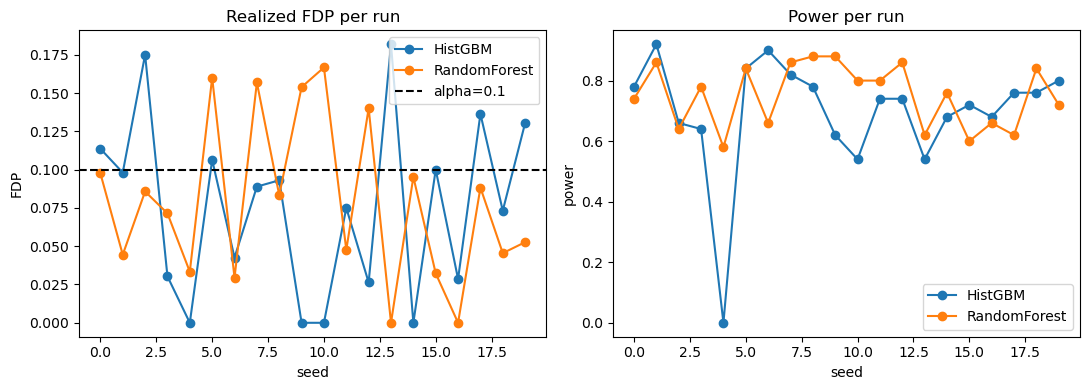

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, r in results.items():
    axes[0].plot(r["fdp"], marker="o", label=name)
    axes[1].plot(r["power"], marker="o", label=name)
axes[0].axhline(ALPHA, color="k", ls="--", label=f"alpha={ALPHA}")
axes[0].set_title("Realized FDP per run"); axes[0].set_xlabel("seed"); axes[0].set_ylabel("FDP"); axes[0].legend()
axes[1].set_title("Power per run"); axes[1].set_xlabel("seed"); axes[1].set_ylabel("power"); axes[1].legend()
plt.tight_layout(); plt.show()

In [20]:
# 6. Downsample to 28x28 before ResNet50 features
FEAT_PATH_28 = HERE / "cvd_features_28x28.npz"

if not FEAT_PATH_28.exists():
    weights = ResNet50_Weights.IMAGENET1K_V2
    preprocess = weights.transforms()
    model = resnet50(weights=weights)
    model.fc = torch.nn.Identity()
    model.eval().to(DEVICE)

    def downsample_preprocess(img):
        img_28 = img.resize((28, 28), resample=Image.BICUBIC)
        return preprocess(img_28)

    all_paths = [(p, 0) for p in cat_paths] + [(p, 1) for p in dog_paths]
    paths_only = [p for p, _ in all_paths]
    labels_only = [y for _, y in all_paths]

    ds_28 = ImgDataset(paths_only, 0, downsample_preprocess)

    def collate_28(batch_idx):
        imgs = torch.stack([ds_28[i][0] for i in batch_idx])
        ys = torch.tensor([labels_only[i] for i in batch_idx])
        return imgs, ys

    loader = DataLoader(
        range(len(paths_only)), batch_size=64, shuffle=False,
        num_workers=4, collate_fn=collate_28,
    )

    feats_28, labels_28 = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="extracting 28x28"):
            f = model(xb.to(DEVICE)).cpu().numpy()
            feats_28.append(f)
            labels_28.append(yb.numpy())

    feats_28 = np.concatenate(feats_28).astype(np.float32)
    labels_28 = np.concatenate(labels_28).astype(np.int64)
    np.savez_compressed(FEAT_PATH_28, feats=feats_28, labels=labels_28)
    print("Saved 28x28 features:", feats_28.shape)
else:
    print("Loading cached 28x28 features from", FEAT_PATH_28)

data_28 = np.load(FEAT_PATH_28)
feats_28 = data_28["feats"]
labels_28 = data_28["labels"]
dogs_28 = feats_28[labels_28 == 1]
cats_28 = feats_28[labels_28 == 0]
print("dogs_28:", dogs_28.shape, "cats_28:", cats_28.shape)

def build_problem_28(rng, n_null=4000, m_test=1000, novelty_frac=0.05):
    """Return xnull, x, is_novelty for 28x28-downsampled features."""
    m1 = int(round(novelty_frac * m_test))
    m0 = m_test - m1
    dog_idx = rng.permutation(len(dogs_28))
    cat_idx = rng.permutation(len(cats_28))
    assert len(dog_idx) >= n_null + m0, "not enough dogs"
    assert len(cat_idx) >= m1, "not enough cats"
    xnull = dogs_28[dog_idx[:n_null]]
    test_dogs = dogs_28[dog_idx[n_null : n_null + m0]]
    test_cats = cats_28[cat_idx[:m1]]
    x = np.concatenate([test_dogs, test_cats], axis=0)
    is_novelty = np.concatenate([np.zeros(m0, bool), np.ones(m1, bool)])
    perm = rng.permutation(len(x))
    return xnull, x[perm], is_novelty[perm]

rng = np.random.default_rng(0)
xnull_28, x_28, is_novelty_28 = build_problem_28(rng, novelty_frac=0.3)
print("xnull_28", xnull_28.shape, "  x_28", x_28.shape, "  novelties in test:", is_novelty_28.sum())

for name, clf in scorers.items():
    proc_28 = AdaDetectERM(scoring_fn=clf, split_size=0.75)
    rejected_28 = proc_28.apply(x_28, ALPHA, xnull_28)
    fdp, power = fdp_power(np.asarray(rejected_28, dtype=int), is_novelty_28)
    print(f"{name:>12s} (28x28) |R|={len(rejected_28):4d}   FDP={fdp:.3f}   Power={power:.3f}")

extracting 28x28:   0%|          | 0/391 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 30128, 14152, 29500, 25976) exited unexpectedly